# **Fully Connected Neural Network on Keras**


Mount Google Drive

In [1]:
# mounting our drive, so that we can access image, feel free to change directory path accrodingly 
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Required Imports

In [2]:
import keras 
from keras.datasets import mnist
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import glob
from IPython.display import display
from PIL import Image
import cv2 as cv
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt


List_files method to get the paths of each file in the directory and save it to a list

In [3]:
def list_files(path):
    #takes a directory and lists the paths of each image in the directory
    result = []
    file_names = sorted([f for f in os.listdir(path) if not f.startswith('.')])
    # print(file_names)
    for file in file_names:
      image_path= os.path.join(path, file)
      result.append(image_path)
      # print(image_path)
    return result

Create_data function to sort through files and check in a metadata CSV whether the label is trash or not

In [4]:
from pandas.core.describe import DataFrameDescriber
import pandas as pd

def create_data(files, csv_file):
  #compares list of files in "files" param to the csv file and creates the y labels for them
  x = []
  y = []
  data = pd.read_csv(csv_file, usecols=['File', 'Contains_Trash'])
  df = pd.DataFrame(data)
  df.set_index("File", inplace = True)
  # display(df)
  for file in files:
    current = df.loc[file[-12:]]
    contains_trash = current.at["Contains_Trash"]
    x.append(file)
    if contains_trash:
      y.append([1])
    else:
      y.append([0])
  # print(x)
  # print(y)
  return x, y


Create lists of trash and no_trash files and shuffle

In [5]:
import random
no_trash = list_files('/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash')
print(no_trash)
print(len(no_trash))
trash = list_files('/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash')
print(trash)
print(len(trash))
random.shuffle(no_trash)
random.shuffle(trash)
files = trash + no_trash[:155]
random.shuffle(files)
print(files)
print(len(files))

['/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0001.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0002.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0003.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0004.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0005.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0006.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0007.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0014.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0015.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0016.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0017.JPG', '/content

Split the files into train and test

In [6]:
(x_train_files, y_train) = create_data(files[:155],'/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/annotations_df-csv2.csv')
(x_test_files, y_test) = create_data(files[155:],'/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/annotations_df-csv2.csv')
print(x_train_files)
print(np.array(y_train).shape)

['/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0027.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0231.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0398.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0030.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0121.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0032.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0170.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/no_trash/DJI_0166.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0299.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0216.JPG', '/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/tnt/trash/DJI_0298.JPG', '/content/drive/MyDrive/JP_CV_

numpy_stack function to take list of file paths, take the images, then convert them to a numpy array

In [ ]:
def numpy_stack(files):
  #takes a list of file paths and then stacks all the images in a numpy array
  to_stack = []
  for filename in files:
    image = cv.imread(filename)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    resized = cv.resize(gray, (224,224))
    # print(resized.shape)
    to_stack.append(resized)
  result = np.stack(to_stack, axis=0)
  print(result.shape)
  return result

Run numpy_stack on train and test files

In [ ]:
# files = ['/content/drive/MyDrive/AllenIsland_Trash/trash1k/1-200/DJI_0001.JPG','/content/drive/MyDrive/AllenIsland_Trash/trash1k/1-200/DJI_0002.JPG','/content/drive/MyDrive/AllenIsland_Trash/trash1k/1-200/DJI_0003.JPG']
x_train = numpy_stack(x_train_files)
x_test = numpy_stack(x_test_files)

(155, 224, 224)
(155, 224, 224)


Print out shape

In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

print("x_train " + str(x_train.shape))
print("y_train " + str(y_train.shape))
print("x_test " + str(x_test.shape))
print("y_test " + str(y_test.shape))

x_train (155, 224, 224)
y_train (155, 1)
x_test (155, 224, 224)
y_test (155, 1)


View y_train file

In [ ]:
display(y_train)

array([[1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
    

In [ ]:
#import your librray, we are using keras

#Get data
# Flatten the images
image_vector_size = 224*224 # 784

# using numpy reshape function we are converting the shape of the dataset from (60000, 28, 28)
# to (60000, 784)
x_train1 = x_train.reshape(x_train.shape[0], image_vector_size)
x_test1 = x_test.reshape(x_test.shape[0], image_vector_size)

# converting labels to one_hot vectors
num_classes = 2 # 0 to 1

print("Before:", y_train[:2])

y_train1 = keras.utils.to_categorical(y_train, num_classes)
y_test1 = keras.utils.to_categorical(y_test, num_classes)

print("after:", y_train1[:2])


Before: [[1]
 [0]]
after: [[0. 1.]
 [1. 0.]]


In [ ]:
## model

from keras.layers import Dense # Dense layers are "fully connected" layers
from keras.models import Sequential 
# Documentation: https://keras.io/models/sequential/

image_size = 224*224 # 200*200
num_classes = 2 # 10 unique digits

# This instantiates a model that will be fully connected
# Meaning consecutive ayers will be connected with each other
model = Sequential()

# The input layer requires the special input_shape parameter which should match
# the shape of our training data, vector dimension of 784

#hidden layer
layer_1 = model.add(Dense(units=2000, activation='sigmoid', input_shape=(image_size,)))
layer_2 = model.add(Dense(units=1000, activation='relu', input_shape=(image_size,)))
layer_3 = model.add(Dense(units=100, activation='sigmoid', input_shape=(image_size,)))


# output layer
layer_5 = model.add(Dense(units=num_classes, activation='sigmoid'))
model.summary()

# this command will compile the whole network 
model.compile(optimizer="sgd", loss='BinaryCrossentropy', metrics=['accuracy'])



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 2000)              100354000 
                                                                 
 dense_12 (Dense)            (None, 1000)              2001000   
                                                                 
 dense_13 (Dense)            (None, 100)               100100    
                                                                 
 dense_14 (Dense)            (None, 2)                 202       
                                                                 
Total params: 102,455,302
Trainable params: 102,455,302
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# train 

# Validation split = 0.1, this means in each training epoch 10% of the training data will be used to calculate validate the model
history = model.fit(x_train, y_train, batch_size=64, epochs=50, verbose=True, validation_split=.2)

#evaluate
print("Testing result:\n")
loss, accuracy  = model.evaluate(x_test1, y_test1, verbose=True)
# model.predict(x_test1)

Epoch 1/50


ValueError: ignored

In [ ]:
!pip3 install keras-visualizer


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from keras_visualizer import visualizer 


In [ ]:
visualizer(model, format='png', view=True) # open image file after visualization

In [ ]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
# From our example of MNIST using Keras 
# importing sklearn evaluation metrics
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, multilabel_confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(x_test1, batch_size=64, verbose=1) # X_test -> text samples
# taking the most probable class with np.argmax
y_pred_bool = np.argmax(y_pred, axis=1) 

#print(y_test)
#print(y_pred_bool)

y_pred = keras.utils.to_categorical(y_pred_bool, num_classes)

## confusion matrix
cm = multilabel_confusion_matrix(y_test1, y_pred)
print(cm) 

# confusion reports
report = classification_report(y_test1, y_pred)
print(classification_report(y_test1, y_pred))


3/3 [==============================] - 0s 7ms/step
[[[74  0]
  [81  0]]

 [[ 0 81]
  [ 0 74]]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        81
           1       0.48      1.00      0.65        74

   micro avg       0.48      0.48      0.48       155
   macro avg       0.24      0.50      0.32       155
weighted avg       0.23      0.48      0.31       155
 samples avg       0.48      0.48      0.48       155



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2000)              100354000 
                                                                 
 dense_1 (Dense)             (None, 1000)              2001000   
                                                                 
 dense_2 (Dense)             (None, 100)               100100    
                                                                 
 dense_3 (Dense)             (None, 2)                 202       
                                                                 
Total params: 102,455,302
Trainable params: 102,455,302
Non-trainable params: 0
_________________________________________________________________


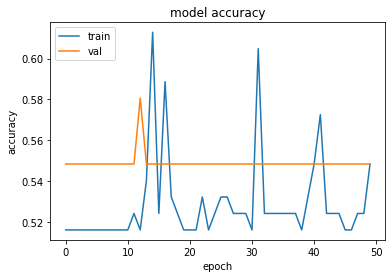

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

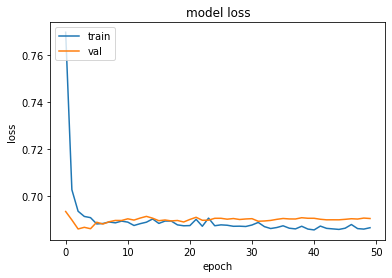

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Let's now train another MLP model with a different classification approach

We will use MNIST inside scikit-learn for this



## We are using Multi-layer perceptron (another name for neural networks) available [here](https://scikit-learn.org/stable/modules/classes.html)

In [ ]:
import warnings
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

### We normalize the data here, meaning we scale them between 0 and 255 (the range of pixel values).

In [ ]:
#Normalize data
x_train1 = x_train1 / 255.0
x_test1 = x_test1 / 255.0

In [ ]:
# Defining a Multi layer perceptro or neural network with a single layer

mlp = MLPClassifier(
    hidden_layer_sizes=(1000,),
    max_iter=50,
    alpha=1e-4,
    solver="sgd",
    verbose=10,
    random_state=1,
    learning_rate_init=0.0001,
)

In [ ]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
    mlp.fit(x_train1, y_train1)

Iteration 1, loss = 1.41242534
Iteration 2, loss = 1.37512008
Iteration 3, loss = 1.36529068
Iteration 4, loss = 1.36594906
Iteration 5, loss = 1.36172209
Iteration 6, loss = 1.35223960
Iteration 7, loss = 1.34271217
Iteration 8, loss = 1.33530401
Iteration 9, loss = 1.32897775
Iteration 10, loss = 1.32248138
Iteration 11, loss = 1.31567482
Iteration 12, loss = 1.30887547
Iteration 13, loss = 1.30218671
Iteration 14, loss = 1.29560813
Iteration 15, loss = 1.28914660
Iteration 16, loss = 1.28271910
Iteration 17, loss = 1.27629239
Iteration 18, loss = 1.26998570
Iteration 19, loss = 1.26382172
Iteration 20, loss = 1.25767311
Iteration 21, loss = 1.25147349
Iteration 22, loss = 1.24529771
Iteration 23, loss = 1.23924134
Iteration 24, loss = 1.23334474
Iteration 25, loss = 1.22743297
Iteration 26, loss = 1.22163964
Iteration 27, loss = 1.21595728
Iteration 28, loss = 1.21046384
Iteration 29, loss = 1.20508949
Iteration 30, loss = 1.19989903
Iteration 31, loss = 1.19480794
Iteration 32, los

Training set score: 0.761290
Test set score: 0.561290


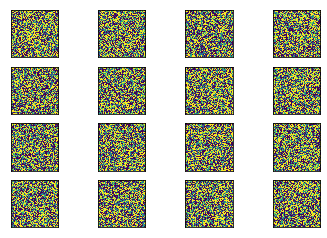

In [ ]:
print("Training set score: %f" % mlp.score(x_train1, y_train1))
print("Test set score: %f" % mlp.score(x_test1, y_test1))
mlp.get_params()
fig, axes = plt.subplots(4, 4)
# use global min / max to ensure all weights are shown on the same scale
vmin, vmax = mlp.coefs_[0].min(), mlp.coefs_[0].max()
for coef, ax in zip(mlp.coefs_[0].T, axes.ravel()):
    ax.matshow(coef.reshape(224, 224), cmap=plt.cm.viridis, vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())

plt.show()

In [ ]:
y_pred = mlp.predict(x_test1)
#number of parameters for MLP
print((sum([a.size for a in mlp.coefs_]) +  
            sum([a.size for a in mlp.intercepts_])))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2000)              100354000 
                                                                 
 dense_1 (Dense)             (None, 1000)              2001000   
                                                                 
 dense_2 (Dense)             (None, 100)               100100    
                                                                 
 dense_3 (Dense)             (None, 2)                 202       
                                                                 
Total params: 102,455,302
Trainable params: 102,455,302
Non-trainable params: 0
_________________________________________________________________
50179002


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import top_k_accuracy_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

#accuracy_score(y_test1, y_pred)
#accuracy_score(y_test1, y_pred)
#precision_score(y_test1, y_pred, average='macro')
#recall_score(y_test1, y_pred, average='macro')
f1_score(y_test1, y_pred, average='macro')

0.6319497495968085

### Not satisfied? Want to try another model to see if your result improves?

In [ ]:
# Lets' use Random forest, which is a great classification model for multi-class problem
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(x_train1, y_train1)
y_pred = rf.predict(x_test1)
#parameters extraction..?
print(rf.get_params())
accuracy_score(y_test1, y_pred)


#f1_score(y_test1, y_pred, average='macro')
#precision_score(y_test1, y_pred, average='macro')
#recall_score(y_test1, y_pred, average='macro')

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'auto', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


0.7354838709677419

* Interested to learn how decision tree and random forest work?
[Here is a quick explanation](https://www.youtube.com/watch?v=NsUqRe-9tb4)


Elapsed time to compute the importances: 0.046 seconds


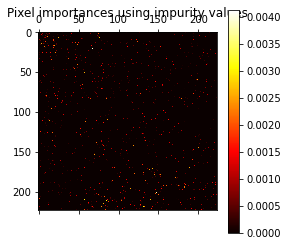

In [ ]:
## see feature importance
import time
start_time = time.time()
img_shape = [224, 224]
importances = rf.feature_importances_
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")
imp_reshaped = importances.reshape(img_shape)
plt.matshow(imp_reshaped, cmap=plt.cm.hot)
plt.title("Pixel importances using impurity values")
plt.colorbar()
plt.show()